### 2_2 - Train based only  on semantic of query

In [1]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt
import pandas as pd

data = pd.read_csv('ds/cleaned_amazon_queries_dataset_en_50k_geo_semant.csv')
cols = ['query' , 'Unnamed: 0' ,'query_chars', 'query_words', 'contains_digit', 'digit_count' , 'avg_word_len' , 'space_count' , 'spec_char_count'] 

#keep only semantic cols
x = data.drop(columns=cols)

In [2]:
x.head(3)

,emb_0,emb_1,emb_2,emb_3,emb_4,emb_5,emb_6,emb_7,emb_8,emb_9,...,emb_40,emb_41,emb_42,emb_43,emb_44,emb_45,emb_46,emb_47,emb_48,emb_49
0,-0.028869,0.041391,0.147372,-0.052076,-0.211408,0.061805,0.067571,0.018281,-0.048607,-0.017753,...,-0.091584,0.011627,0.097332,0.024175,-0.122666,0.036653,-0.021834,-0.018718,-0.050285,-0.045307
1,0.040609,-0.083417,-0.033752,0.387210,0.141060,-0.255175,-0.004326,-0.271619,0.005207,-0.017319,...,-0.046814,0.022521,0.077184,0.015270,-0.049487,0.060322,-0.030696,0.007400,0.087071,-0.105523
2,-0.052110,0.212552,-0.001981,-0.105464,0.170102,-0.047175,0.011192,0.144185,0.037950,0.018954,...,-0.040206,-0.162135,0.078060,0.077822,-0.008254,-0.028601,0.086238,0.023818,0.012644,0.042072


#### Kmeans

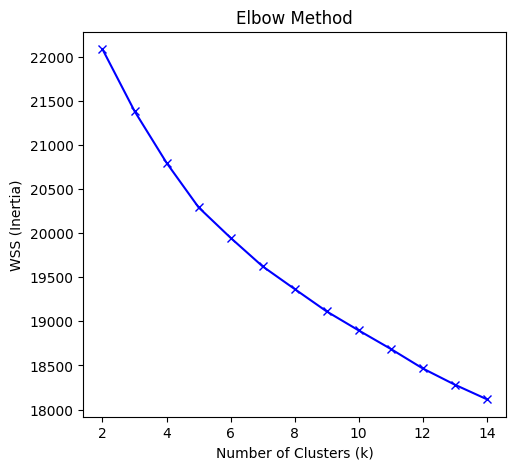

In [3]:
#elbow method to find best k

wss = []
silhouette_avg = []
k_range = range(2, 15) 

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    cluster_labels = kmeans.fit_predict(x)
    
    #  WSS for Elbow
    wss.append(kmeans.inertia_)
    

# Plotting the results for your paper
plt.figure(figsize=(12, 5))

# Plot Elbow
plt.subplot(1, 2, 1)
plt.plot(k_range, wss, 'bx-')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('WSS (Inertia)')
plt.title('Elbow Method')


plt.show()


#no clear point

In [ ]:
#find k based on silhouette_score

import numpy as np

#to make it fast
sample_idx = np.random.choice(len(x), size=5000, replace=False)
x_sample = x.iloc[sample_idx]

for k in range(2, 10, 1):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    
    labels = kmeans.fit_predict(x_sample)
    score = silhouette_score(x_sample, labels)

    print(k, score)

for k in range(100, 200, 10):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    
    labels = kmeans.fit_predict(x_sample)
    score = silhouette_score(x_sample, labels)

    print(k, score)


# best based on silhouette_score is k = 2

2 0.06093750240613458
3 0.04486245281665771
4 0.043877159149035456
5 0.04402139622011035
6 0.046822948601469995
7 0.04881394410023388
8 0.047373043509531594
9 0.051982938553653456
100 0.06353270611346881
110 0.06410518640204813
120 0.06260323877803753
130 0.06403471642615609
140 0.06435693853993033
150 0.06526993506883669
160 0.0656234707387451
170 0.06724661182794868
180 0.06651087413117804
190 0.06617729070621332


In [4]:
#Kmeans Model 

kmeans_final = KMeans(n_clusters=2, random_state=42, n_init=10)

# predict
data['kmeans_cluster'] = kmeans_final.fit_predict(x)

# check clusters
print(data['kmeans_cluster'].value_counts())

kmeans_cluster
0    38069
1    11931
Name: count, dtype: int64


In [8]:
for i in range(2):
    print(f"\n--- Examples of Cluster {i} ---")
    print(data[data['kmeans_cluster'] == i]['query'].head(10).values)


--- Examples of Cluster 0 ---
<StringArray>
[                     'workout weights',
                  'nintendo gift cards',
                        'urban skin rx',
                            'bird seed',
          '+foot cream without alcohol',
 'brother tn730 high yield black toner',
                            '60 lashes',
                         'cpap filters',
        'long cord lavalier microphone',
              'tumblers bulk wholesale']
Length: 10, dtype: str

--- Examples of Cluster 1 ---
<StringArray>
[    'hot pink berets for women',                 'black zipties',
      'embrace the suck t shirt',                'white headband',
           'women's dress socks', 'dmc counted cross stitch kits',
         'orange shirts for men',   '0 size 4 pads without wings',
            'old ladies glasses',                'diapers size 3']
Length: 10, dtype: str


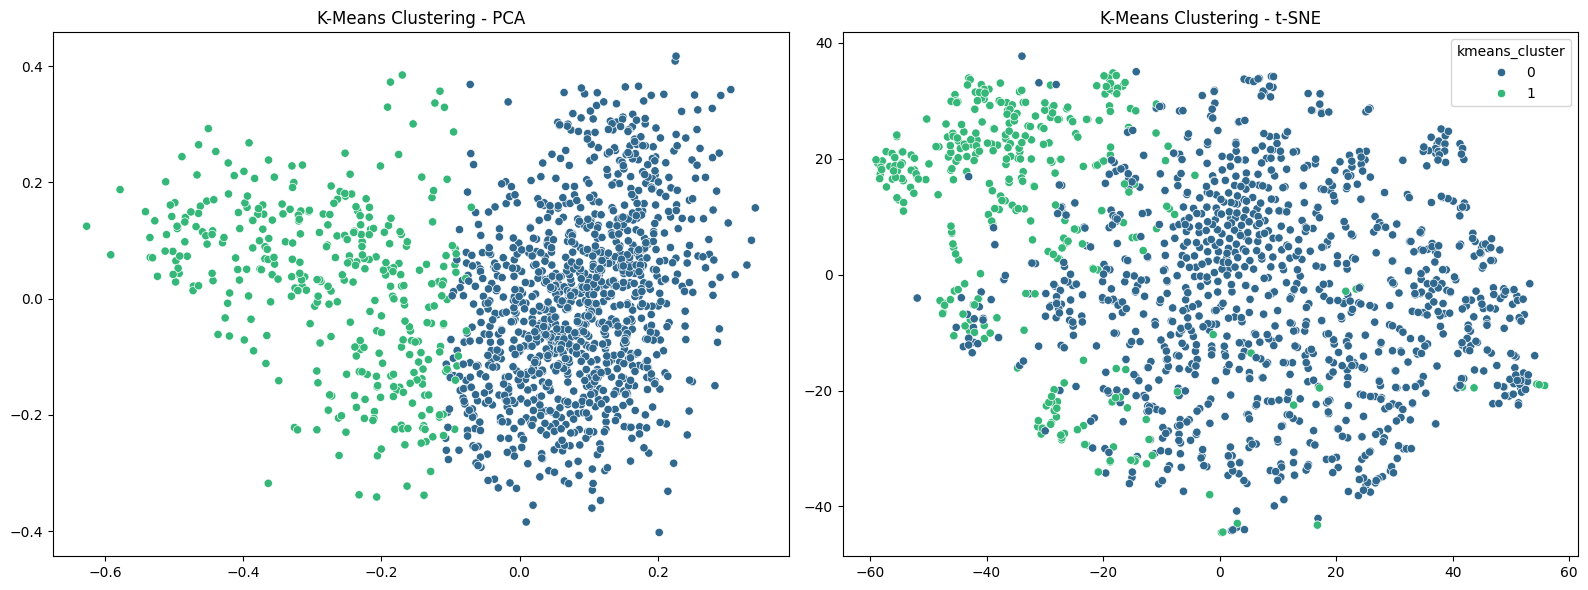

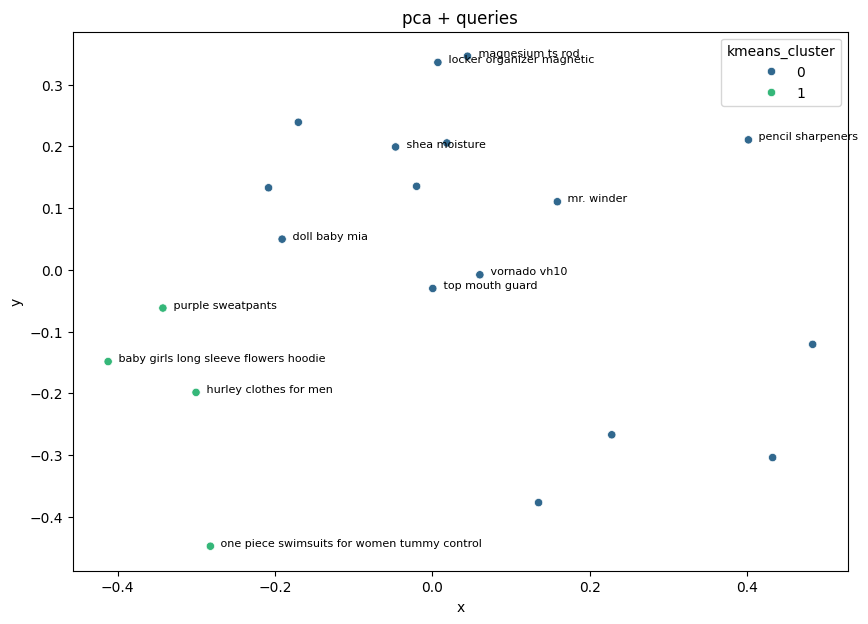

In [57]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
import numpy as np

#to reduce size of showing graphes
sample_idx = np.random.choice(len(x), 1500, replace=False)
x_sample = x.iloc[sample_idx]
cluster_sample = data.iloc[sample_idx]['kmeans_cluster']

pca = PCA(n_components=2)
X_pca = pca.fit_transform(x_sample)


tsne = TSNE(n_components=2, perplexity=30, random_state=42)
X_tsne = tsne.fit_transform(x_sample)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))


sns.scatterplot(
    x=X_pca[:, 0],
    y=X_pca[:, 1],
    hue=cluster_sample,
    palette='viridis',
    ax=axes[0],
    legend=False
)
axes[0].set_title("K-Means Clustering - PCA")

sns.scatterplot(
    x=X_tsne[:, 0],
    y=X_tsne[:, 1],
    hue=cluster_sample,
    palette='viridis',
    ax=axes[1]
)
axes[1].set_title("K-Means Clustering - t-SNE")

plt.tight_layout()
plt.show()


# part2 with querise

sample = data.sample(n=20, random_state=38)
x_sample = x.iloc[sample.index]

X_pca = pca.fit_transform(x_sample)
sample['x'] = X_pca[:,0]
sample['y'] = X_pca[:,1]

plt.figure(figsize=(10,7))

sns.scatterplot(
    data=sample,
    x='x',
    y='y',
    hue='kmeans_cluster',
    palette='viridis'
)

# show only 2–3 labels per cluster
for cluster in sample['kmeans_cluster'].unique():
    cluster_points = sample[sample['kmeans_cluster'] == cluster].head(8)
    for _, row in cluster_points.iterrows():
        plt.text(row['x'], row['y'], "   "+row['query'], fontsize=8)

plt.title("pca + queries")
plt.show()

#### GMM

In [52]:
from sklearn.mixture import GaussianMixture

#to make it fast
sample_idx = np.random.choice(len(x), size=5000, replace=False)
x_sample = x.iloc[sample_idx]
bic_scores = []

for k in range(2, 10):
    gmm = GaussianMixture(n_components=k, random_state=42)
    gmm.fit(x_sample)

    bic = gmm.bic(x_sample)
    bic_scores.append(bic)

    print(f"k={k}, BIC={bic:.2f}")

k=2, BIC=-491477.85
k=3, BIC=-497092.24
k=4, BIC=-495278.60
k=5, BIC=-490008.88
k=6, BIC=-483915.81
k=7, BIC=-480486.88
k=8, BIC=-474870.66
k=9, BIC=-468746.00


In [53]:


#gmm model
gmm = GaussianMixture(n_components=3, random_state=42)


data['gmm_cluster'] = gmm.fit_predict(x)


for i in range(3):
    print(f"\n--- GMM Cluster {i} ---")
    print(data[data['gmm_cluster'] == i]['query'].head(5).values)


--- GMM Cluster 0 ---
<StringArray>
[      'brother tn730 high yield black toner',
                                  '60 lashes',
              'long cord lavalier microphone',
 'hyundai accent steering wheel sign sticker',
                           'new era snapback']
Length: 5, dtype: str

--- GMM Cluster 1 ---
<StringArray>
[          'workout weights',       'nintendo gift cards',
            'seat belt belt',        'dunkin donuts toys',
 'hot pink berets for women']
Length: 5, dtype: str

--- GMM Cluster 2 ---
<StringArray>
[              'urban skin rx',                   'bird seed',
 '+foot cream without alcohol',                'cpap filters',
     'tumblers bulk wholesale']
Length: 5, dtype: str


In [54]:
# probability 
probs = gmm.predict_proba(x)

data['gmm_confidence'] = probs.max(axis=1)

print(data[['query', 'gmm_cluster', 'gmm_confidence']].head(10))

                                  query  gmm_cluster  gmm_confidence
0                       workout weights            1        0.999314
1                   nintendo gift cards            1        0.582680
2                         urban skin rx            2        0.809994
3                             bird seed            2        1.000000
4           +foot cream without alcohol            2        1.000000
5  brother tn730 high yield black toner            0        0.997471
6                             60 lashes            0        0.945578
7                          cpap filters            2        0.999385
8         long cord lavalier microphone            0        1.000000
9               tumblers bulk wholesale            2        1.000000


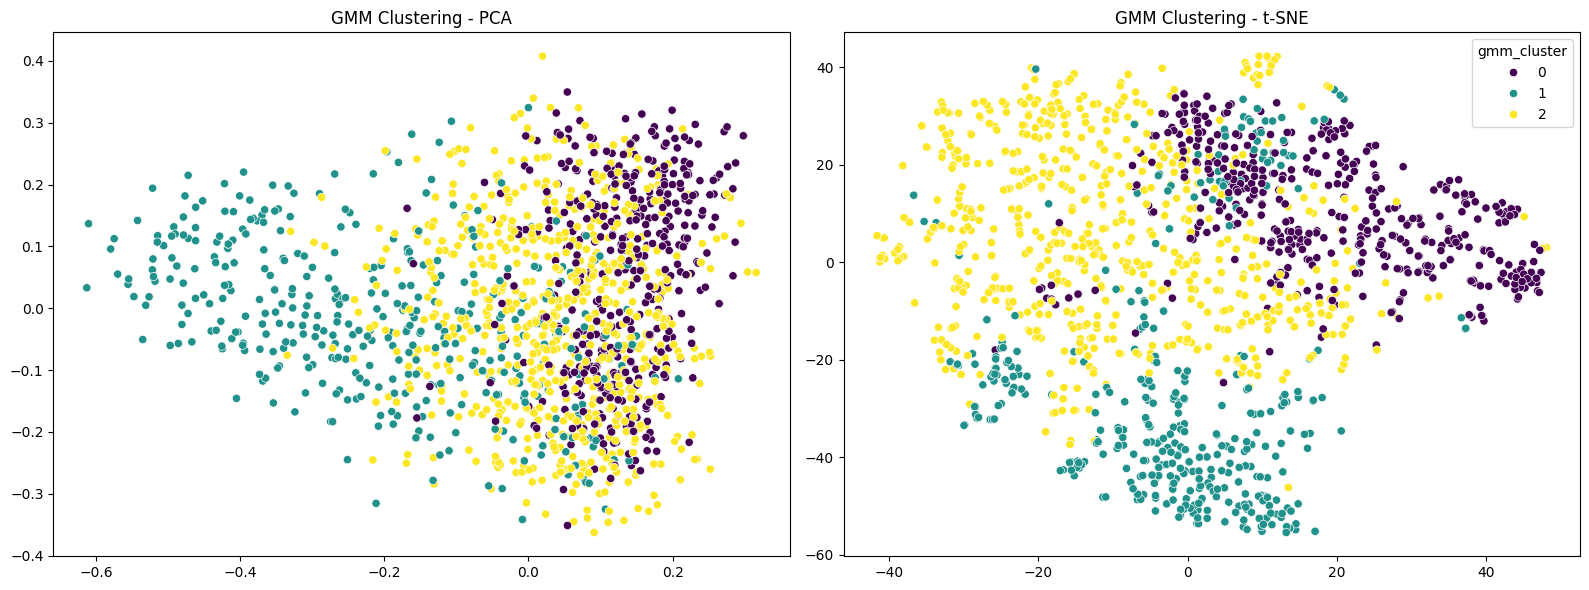

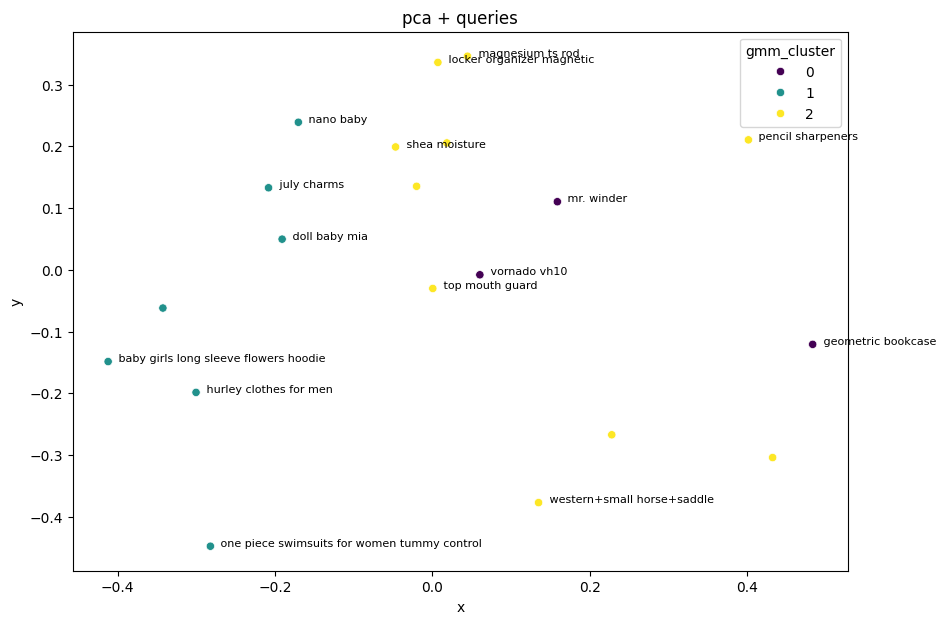

In [60]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
import numpy as np

#to reduce size of showing graphes
sample_idx = np.random.choice(len(x), 1500, replace=False)
x_sample = x.iloc[sample_idx]
cluster_sample = data.iloc[sample_idx]['gmm_cluster']

pca = PCA(n_components=2)
X_pca = pca.fit_transform(x_sample)


tsne = TSNE(n_components=2, perplexity=30, random_state=42)
X_tsne = tsne.fit_transform(x_sample)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))


sns.scatterplot(
    x=X_pca[:, 0],
    y=X_pca[:, 1],
    hue=cluster_sample,
    palette='viridis',
    ax=axes[0],
    legend=False
)
axes[0].set_title("GMM Clustering - PCA")

sns.scatterplot(
    x=X_tsne[:, 0],
    y=X_tsne[:, 1],
    hue=cluster_sample,
    palette='viridis',
    ax=axes[1]
)
axes[1].set_title("GMM Clustering - t-SNE")

plt.tight_layout()
plt.show()


# part2 with querise

sample = data.sample(n=20, random_state=38)
x_sample = x.iloc[sample.index]

X_pca = pca.fit_transform(x_sample)
sample['x'] = X_pca[:,0]
sample['y'] = X_pca[:,1]

plt.figure(figsize=(10,7))

sns.scatterplot(
    data=sample,
    x='x',
    y='y',
    hue='gmm_cluster',
    palette='viridis'
)

# show only 2–3 labels per cluster
for cluster in sample['gmm_cluster'].unique():
    cluster_points = sample[sample['gmm_cluster'] == cluster].head(6)
    for _, row in cluster_points.iterrows():
        plt.text(row['x'], row['y'], "   "+row['query'], fontsize=8)

plt.title("pca + queries")
plt.show()

#### DBscan

In [61]:
from sklearn.neighbors import NearestNeighbors
import matplotlib.pyplot as plt
import numpy as np

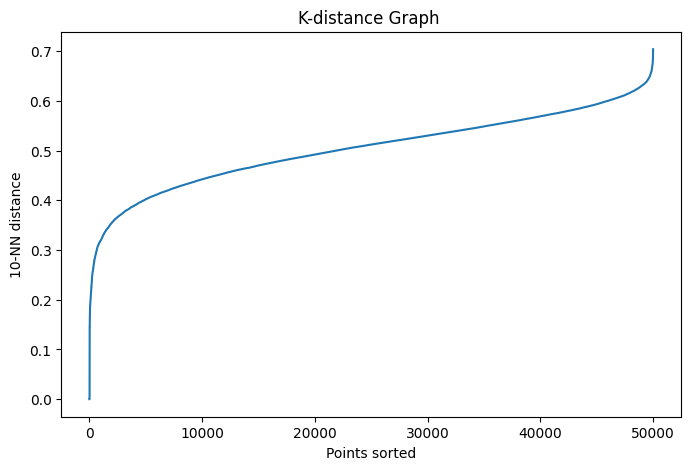

In [ ]:
import numpy as np
from sklearn.neighbors import NearestNeighbors
import matplotlib.pyplot as plt

k = 10  
neighbors = NearestNeighbors(n_neighbors=k)
neighbors_fit = neighbors.fit(x)
distances, indices = neighbors_fit.kneighbors(x)


distances = np.sort(distances[:, k-1])

plt.figure(figsize=(8,5))
plt.plot(distances)
plt.title("K-distance Graph ")
plt.xlabel("Points sorted")
plt.ylabel(f"{k}-NN distance")
plt.show()

#

In [63]:
from sklearn.preprocessing import RobustScaler
from sklearn.cluster import DBSCAN

dbscan = DBSCAN(
    eps=0.5,min_samples=10 , metric='euclidean'
)

labels = dbscan.fit_predict(x)

data['db_cluster'] = labels


print(data['db_cluster'].value_counts())

for c in sorted(data['db_cluster'].unique()):
    print("\n Cluster", c)
    print(data[data['db_cluster'] == c]['query'].head(5).tolist())

db_cluster
 0     33031
-1     15073
 5       195
 10       98
 9        72
       ...  
 94        6
 35        5
 88        5
 97        5
 95        2
Name: count, Length: 100, dtype: int64

 Cluster -1
['+foot cream without alcohol', 'tumblers bulk wholesale', 'carhartt lined cap', 'hyundai accent steering wheel sign sticker', 'bronze toilet paper holder']

 Cluster 0
['workout weights', 'nintendo gift cards', 'urban skin rx', 'bird seed', 'brother tn730 high yield black toner']

 Cluster 1
['0 size 4 pads without wings', 'overnight pads for women extra heavy without wings', 'always maxi overnight pads without wings', '0 size 4 pads without wings', 'overnight pads for women extra heavy without wings']

 Cluster 2
['card holder lanyard', 'rilakkuma lanyard', 'lanyards for keys', 'seven dwarfs lanyard', 'kings lanyard']

 Cluster 3
['10 m syringe for liquid without needle', '3ml syringe', '.25 ml syringe without needle', 'empty syringes without needles', '60 ml syringe without needle

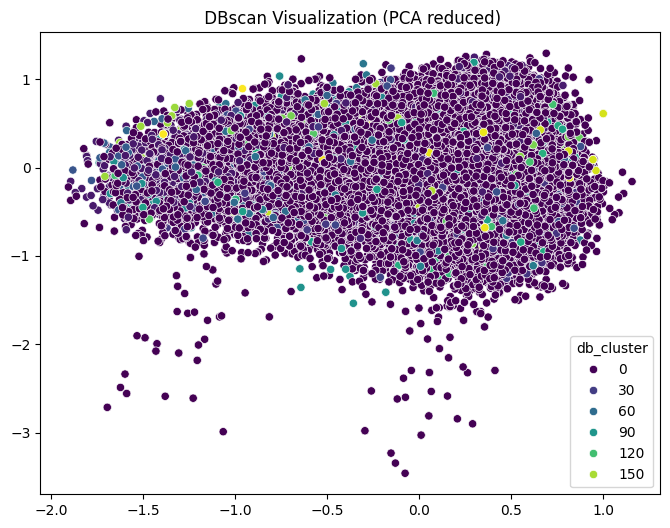

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
import numpy as np

#to reduce size of showing graphes
sample_idx = np.random.choice(len(x), 1500, replace=False)
x_sample = x.iloc[sample_idx]
cluster_sample = data.iloc[sample_idx]['db_cluster']

pca = PCA(n_components=2)
X_pca = pca.fit_transform(x_sample)


tsne = TSNE(n_components=2, perplexity=30, random_state=42)
X_tsne = tsne.fit_transform(x_sample)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))


sns.scatterplot(
    x=X_pca[:, 0],
    y=X_pca[:, 1],
    hue=cluster_sample,
    palette='viridis',
    ax=axes[0],
    legend=False
)
axes[0].set_title("DBscan Clustering - PCA")

sns.scatterplot(
    x=X_tsne[:, 0],
    y=X_tsne[:, 1],
    hue=cluster_sample,
    palette='viridis',
    ax=axes[1]
)
axes[1].set_title("DBscan Clustering - t-SNE")

plt.tight_layout()
plt.show()

### hdbscan

In [ ]:
import hdbscan

clusterer = hdbscan.HDBSCAN(
    min_cluster_size=7,   
    min_samples=10,        
    metric='euclidean'
)

labels_hdb = clusterer.fit_predict(x)

data['hdbscan_cluster'] = labels_hdb

print(data['hdbscan_cluster'].value_counts())

for c in sorted(data['hdbscan_cluster'].unique()):
    print(f"\n HDBscan Cluster {c} ---")
    print(data[data['hdbscan_cluster'] == c]['query'].head(5).tolist())

hdbscan_cluster
 1    48153
-1     1811
 0       36
Name: count, dtype: int64

 HDBscan Cluster -1 ---
['06 suzuki 600 side fairing not painted', 'jewellery+box+small+crystal', "'oh no not you again' door mat", 'hummingbird feeders for outdoors glass', '10 lb resistance band without handles']

 HDBscan Cluster 0 ---
['I would purchase a laptop with good processing power, a RAM of above 10GB, a good video card, and good battery power.', "A Lenovo like mine its a little notebook it's fab. It would be black in colour ", 'A laptop which runs faster and has more capacity to run downloaded software ', "A Lenovo like mine its a little notebook it's fab. It would be black in colour ", 'Something that’s lightweight to carry and can be used to surf the internet and use Microsoft Office']

 HDBscan Cluster 1 ---
['workout weights', 'nintendo gift cards', 'urban skin rx', 'bird seed', '+foot cream without alcohol']


### evaluating

In [32]:
from sklearn.metrics import silhouette_score , calinski_harabasz_score , davies_bouldin_score
import numpy as np

In [ ]:
#to calculate silhout scor fast
sample_idx = np.random.choice(len(x), size=5000, replace=False)
X_sample = x.iloc[sample_idx].values

models = {
    "kmeans": data['kmeans2_cluster'],
    "gmm": data['gmm_cluster'],
    "dbscan": data['db_cluster'],
    "hdbscan": data['hdbscan_cluster']
}

results = []

for name, column in models.items():
    
    labels = column.values
    X_values = x.values
    
    # noise remove dbscan and hdb
    mask = labels != -1
    
    # less clusters
    if len(set(labels[mask])) < 2:
        continue

    #  silhouette on 5k sam
    labels_sample = labels[sample_idx]
    mask_sample = labels_sample != -1
    
    if len(set(labels_sample[mask_sample])) > 1:
        sil = silhouette_score(
            X_sample[mask_sample],
            labels_sample[mask_sample]
        )
    else:
        sil = np.nan

    
    ch = calinski_harabasz_score(X_values[mask], labels[mask])
    db = davies_bouldin_score(X_values[mask], labels[mask])

    results.append({
        "model": name,
        "silhouette": sil,
        "calinski_harabasz": ch,
        "davies_bouldin": db,
        "n_clusters": len(set(labels[mask]))
    })

results_df = pd.DataFrame(results)
print(results_df)

     model  silhouette  calinski_harabasz  davies_bouldin  n_clusters
0   kmeans    0.042962        2143.956106        4.228121           3
1      gmm    0.036246         937.415147        4.142466           3
2   dbscan    0.162533          78.767989        1.324213         174
3  hdbscan    0.263085          89.350900        1.062665           2
